# Applied Maschine Learning - Project Report

## 1. Data
*Instructions: Describe the dataset, its source, and why it was chosen. Detail the preprocessing steps.*

**Dataset Source:** PUMS (Public Use Microdata Sample) from the US Census Bureau.

In [29]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import logging
from datetime import datetime
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import joblib

# Configuration
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
logging.basicConfig(level=logging.INFO, format='%(message)s')
logger = logging.getLogger()

# Define Paths
DATA_DIR = '00 data/raw/'
RAW_FILES = [
    'connecticut.csv', 'maine.csv', 'massachusetts.csv', 
    'new_hampshire.csv', 'rhode_island.csv', 'vermont.csv'
]

### 1.1 Data Understanding & Exploration

**Objectives:**
*   **Initial Analysis:** Inspect data shape, missing values, and data quality.
*   **Statistical Checks:** Analyze variance, correlation, and mutual information.
*   **Health Indicators:** Explore the distribution of health insurance coverage types and their combinations.
*   **Feature Distribution:** Visualize key demographic and economic features.

#### Load Data

In [44]:
print("Loading raw data from New England states...")
dfs = []
# Deduplicate file list to prevent double loading
unique_files = sorted(list(set(RAW_FILES)))

for file in unique_files:
    path = os.path.join(DATA_DIR, file)
    if os.path.exists(path):
        print(f"Loading {file}...")
        dfs.append(pd.read_csv(path))
    else:
        print(f"Warning: {file} not found at {path}")


df_raw = pd.concat(dfs, ignore_index=True)
print(f"All data loaded. Total rows: {len(df_raw):,}")

Loading raw data from New England states...
Loading connecticut.csv...
Loading maine.csv...
Loading massachusetts.csv...
Loading new_hampshire.csv...
Loading rhode_island.csv...
Loading vermont.csv...
All data loaded. Total rows: 158,895


#### Data Exploration
Within this step we are looking at
- the **shape** of the dataframe,
- **missing values**,
- **correlation** with HINS4 (Medicaid),
- **mutual information** with HINS4 (medicaid) and
- **class imbalance** and **combinations** of different insurance types (HINS)

##### Shape

In [32]:
# Head & Shape
print(f"Data Shape: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns")
display(df_raw.head(5))

Data Shape: 158,895 rows, 286 columns


,RT,SERIALNO,DIVISION,SPORDER,PUMA,REGION,STATE,ADJINC,PWGTP,AGEP,...,PWGTP71,PWGTP72,PWGTP73,PWGTP74,PWGTP75,PWGTP76,PWGTP77,PWGTP78,PWGTP79,PWGTP80
0,P,2024GQ0000164,1,1,20500,1,9,1015250,13,36,...,14,15,13,13,16,16,12,14,13,11
1,P,2024GQ0000190,1,1,20603,1,9,1015250,84,21,...,82,80,83,88,83,81,83,79,83,86
2,P,2024GQ0000304,1,1,20603,1,9,1015250,52,85,...,53,55,49,50,54,53,51,52,53,53
3,P,2024GQ0000319,1,1,20201,1,9,1015250,56,19,...,65,60,5,125,50,50,55,4,111,5
4,P,2024GQ0000366,1,1,20203,1,9,1015250,29,19,...,55,32,28,27,55,3,2,2,3,33


##### Missing Values


--- Missing Values ---

Columns with Missing Values:
           Missing Count Percentage
GCM               158250     99.59%
DRAT              156850     98.71%
GCR               156389     98.42%
FHINS5C           155713     98.00%
SFN               155527     97.88%
SFR               155527     97.88%
FOD2P             151740     95.50%
MLPCD             151228     95.17%
MLPE              151228     95.17%
MLPA              151228     95.17%
MLPB              151228     95.17%
MLPHJ             151228     95.17%
MLPIK             151228     95.17%
VPSP              151228     95.17%
MLPFG             151228     95.17%
DRATX             149514     94.10%
CITWP             147305     92.71%
MIGSP             142619     89.76%
MIGPUMA           142619     89.76%
DECADE            135340     85.18%
YOEP              135340     85.18%
ESP               134480     84.63%
NOP               134480     84.63%
LANP              132345     83.29%
ENG               132345     83.29%
FHINS4C   

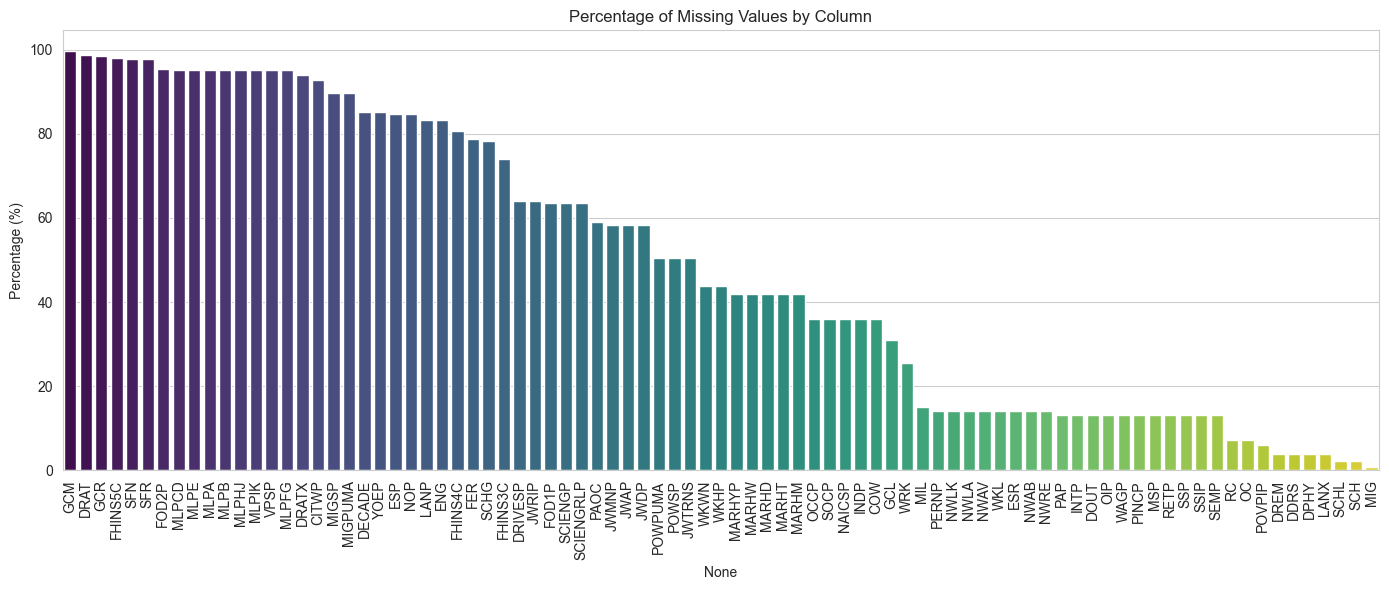

In [33]:
# Missing Values
print("\n--- Missing Values ---")
missing = df_raw.isnull().sum()
missing = missing[missing > 0]

missing_pct = (missing / len(df_raw)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})

# Sort by percentage descending
missing_df = missing_df.sort_values('Percentage', ascending=False)

# List with column and percentage
print("\nColumns with Missing Values:")
print(missing_df.to_string(formatters={'Percentage': '{:,.2f}%'.format}))

# Chart: Distribution of columns with missing values (ordered by percentage)
plt.figure(figsize=(14, 6))
sns.barplot(x=missing_df.index, y=missing_df['Percentage'], palette='viridis', order=missing_df.index)
plt.title('Percentage of Missing Values by Column')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

##### Duplicates

In [34]:
# Duplicate Rows Analysis
print("\n--- Duplicate Rows Analysis ---")

# Count duplicate rows
dup_count = df_raw.duplicated(keep=False).sum()  # keep=False marks all duplicates as True

# Calculate percentage
dup_pct = (dup_count / len(df_raw)) * 100

# Print results
print(f"Duplicate Rows: {dup_count:,} ({dup_pct:.2f}% of dataset)")



--- Duplicate Rows Analysis ---
Duplicate Rows: 0 (0.00% of dataset)


##### Correlation


--- Correlation with Medicaid (HINS4) ---

Features Correlated with Medicaid:
           Correlation Coefficient
PUBCOV                    0.596673
PRIVCOV                   0.572715
POVPIP                    0.466395
HINS1                     0.459684
ESP                       0.415404
NOP                       0.412275
SFR                       0.296759
SSIP                      0.267046
DOUT                      0.267019
DREM                      0.258506
DIS                       0.235018
SCHL                      0.232090
WKL                       0.228621
ESR                       0.220062
RELSHIPP                  0.217290
MSP                       0.213328
MAR                       0.209149
WRK                       0.206229
PINCP                     0.203106
ENG                       0.197250
DDRS                      0.195255
PERNP                     0.192473
WAGP                      0.192362
DPHY                      0.184189
OCCP                      0.160675
WKHP       

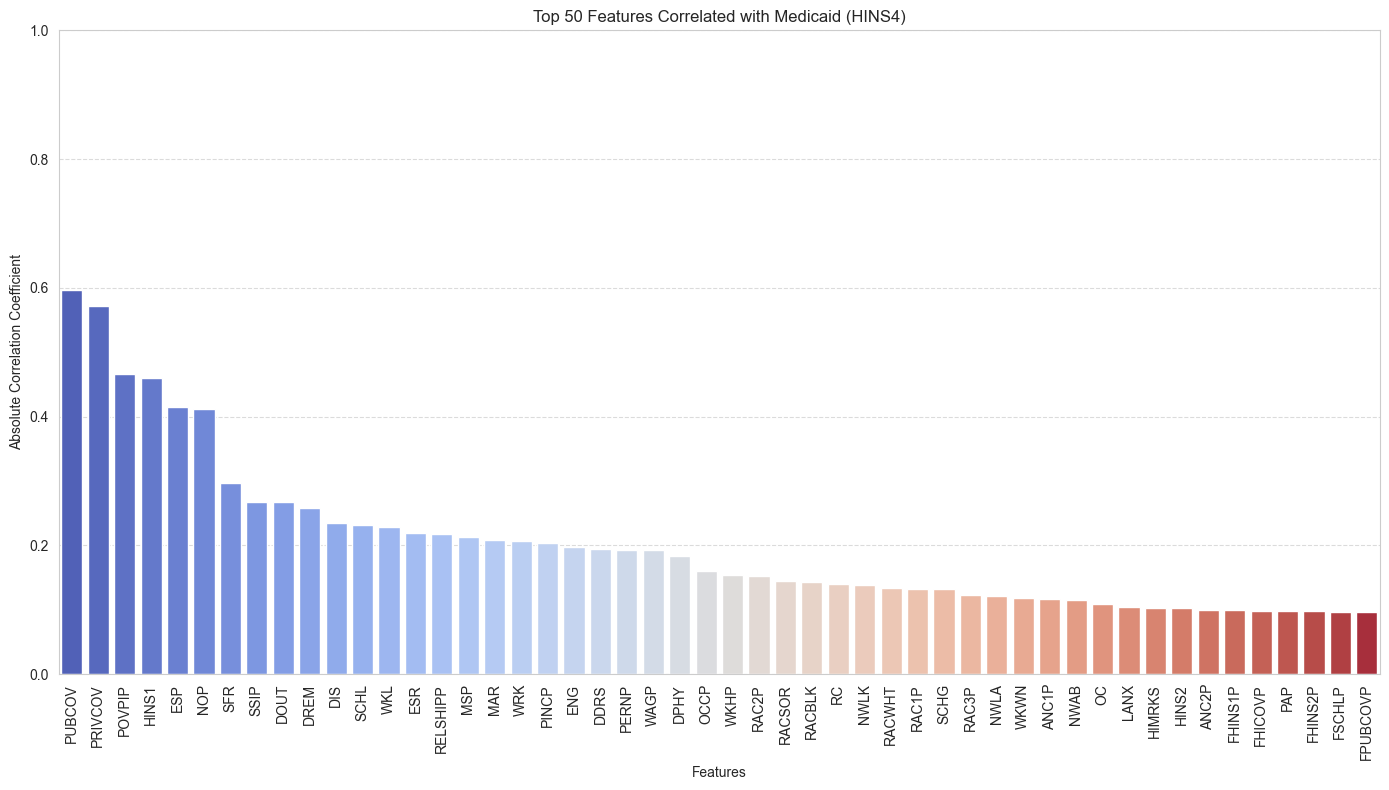

In [35]:
# Correlation with Medicaid (HINS4)
print("\n--- Correlation with Medicaid (HINS4) ---")
# Define numeric columns
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns
# Calculate correlation of all numeric features with HINS4
corr_with_medicaid = df_raw[numeric_cols].corrwith(df_raw['HINS4']).abs().sort_values(ascending=False)
# Remove HINS4 itself from the results
corr_with_medicaid = corr_with_medicaid.drop('HINS4', errors='ignore')

# Convert to DataFrame to add headers
corr_df = pd.DataFrame(corr_with_medicaid, columns=['Correlation Coefficient'])

# Print all features correlated with Medicaid with headers
print("\nFeatures Correlated with Medicaid:")
print(corr_df.to_string())

# Get top 50 features
top_50 = corr_df.head(50)
# Print highly correlated features
high_corr = top_50[top_50['Correlation Coefficient'] > 0.3]  # Adjust threshold as needed
print(f"\nFeatures with correlation > 0.3 to Medicaid: {len(high_corr)} features")

# Plot as a bar chart with switched axes
plt.figure(figsize=(14, 8))
sns.barplot(x=top_50.index, y=top_50['Correlation Coefficient'], palette='coolwarm')
plt.title('Top 50 Features Correlated with Medicaid (HINS4)')
plt.xlabel('Features')
plt.ylabel('Absolute Correlation Coefficient')
plt.ylim(0, 1)  # Correlation ranges from 0 to 1
plt.xticks(rotation=90)  # Rotate feature names for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


##### Mutual Information


--- Mutual Information Analysis ---
Features with Mutual Information towards Medicaid:
PUBCOV       0.201729
PRIVCOV      0.154251
HINS1        0.108743
POVPIP       0.104277
PINCP        0.068046
SCHL         0.050310
OCCP         0.049189
SSIP         0.041697
WAGP         0.038820
RELSHIPP     0.038537
MSP          0.037813
PERNP        0.035743
POWPUMA      0.035710
FOD1P        0.034758
INDP         0.034735
SCIENGRLP    0.031862
SCIENGP      0.029876
ESR          0.029718
WKHP         0.029197
JWDP         0.028989
JWTRNS       0.028872
WKWN         0.027749
DREM         0.027285
POWSP        0.026717
WKL          0.026585
COW          0.026475
PWGTP        0.026440
ANC1P        0.026381
WRK          0.026373
DOUT         0.026190
JWRIP        0.025138
JWAP         0.022367
MARHYP       0.022051
DIS          0.020836
JWMNP        0.019427
FHINS4C      0.019256
PWGTP69      0.019144
FJWDP        0.018710
RAC2P        0.018539
HIMRKS       0.018385
NWAB         0.018174
RAC3P     

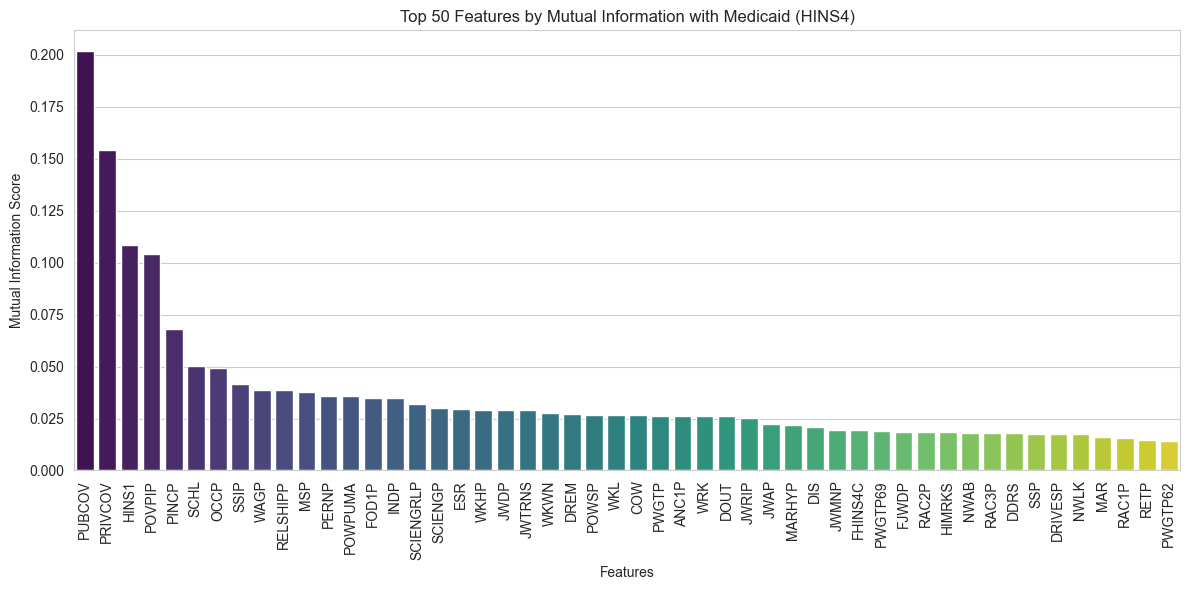

In [36]:
# Mutual Information
print("\n--- Mutual Information Analysis ---")
# Sample for speed
sample_df = df_raw.sample(min(5000, len(df_raw)), random_state=42).fillna(0)
X_mi = sample_df.select_dtypes(include=[np.number]).drop(columns=['HINS4'], errors='ignore')
y_mi = sample_df['HINS4']

mi = mutual_info_classif(X_mi, y_mi, random_state=42)
mi_series = pd.Series(mi, index=X_mi.columns).sort_values(ascending=False)

# Print ALL features by Mutual Information (sorted)
print("Features with Mutual Information towards Medicaid:")
print(mi_series.to_string())

# Plot distribution of TOP 50 Mutual Information scores
plt.figure(figsize=(12, 6))
top_50_mi = mi_series.head(50)  # Get top 50 features
sns.barplot(x=top_50_mi.index, y=top_50_mi.values, palette='viridis')
plt.title('Top 50 Features by Mutual Information with Medicaid (HINS4)')
plt.xlabel('Features')
plt.ylabel('Mutual Information Score')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


##### Class Imbalance & Combinations


--- Health Indicators ---
Class Imbalance (HINS4 - Medicaid):
Medicaid Status  Proportion
             No    0.806029
            Yes    0.193971



--- Health Indicators ---
Class Imbalance (HINS4 - Medicaid):
Medicaid Status  Proportion
             No    0.806029
            Yes    0.193971


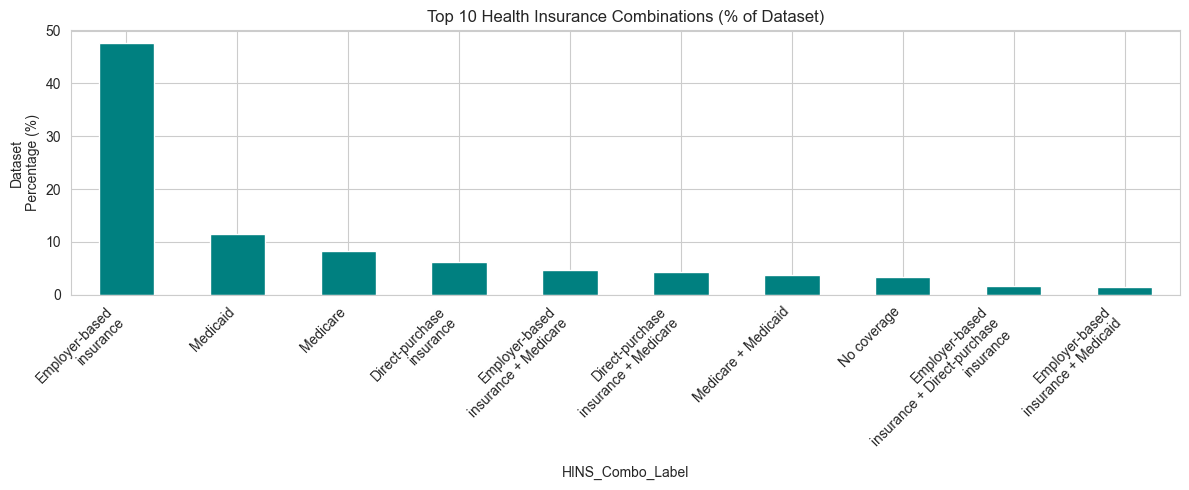

In [39]:
# Health Indicators & Medicaid Class Imbalance
print("\n--- Health Indicators ---")
# Define HINS labels
hins_labels = {
    'HINS1': 'Employer-based\ninsurance',
    'HINS2': 'Direct-purchase\ninsurance',
    'HINS3': 'Medicare',
    'HINS4': 'Medicaid',
    'HINS5': 'Tricare/VA',
    'HINS6': 'Other public\ninsurance',
    'HINS7': 'No coverage'
}
# Replace 1/2 with descriptive labels for display
dist = df_raw['HINS4'].map({1: 'Yes', 2: 'No'}).value_counts(normalize=True)

# Convert to DataFrame to add headers
dist_df = pd.DataFrame(dist).reset_index()
dist_df.columns = ['Medicaid Status', 'Proportion']

print(f"Class Imbalance (HINS4 - {hins_labels['HINS4']}):")
print(dist_df.to_string(index=False))

# HINS Combinations Chart with labels and percentages
hins_cols = sorted([c for c in df_raw.columns if c.startswith('HINS') and len(c) == 5])
if hins_cols:
    # Create a mapping function for the combination labels
    def map_hins_combo(row):
        combo_parts = []
        for col in hins_cols:
            val = row[col]
            if val == 1:
                combo_parts.append(hins_labels.get(col, col))
        return ' + '.join(combo_parts) if combo_parts else 'No coverage'
    df_raw['HINS_Combo_Label'] = df_raw.apply(map_hins_combo, axis=1)
    top_combos = df_raw['HINS_Combo_Label'].value_counts(normalize=True).head(10) * 100  # Convert to percentage

    plt.figure(figsize=(12, 5))
    ax = top_combos.plot(kind='bar', color='teal')
    plt.title('Top 10 Health Insurance Combinations (% of Dataset)')
    # Set multiline x and y axis labels
    plt.ylabel('Dataset\nPercentage (%)')
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, ha='right')
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    plt.show()


## 2. Data Cleaning and Feature Engineering
In this section, we process the raw data through a structured pipeline involving attribute selection, data cleaning, and feature engineering.

### 2.1 Attribute Dropping
We filter the dataset to retain only the most relevant features for our analysis, grouped by domain. This step reduces dimensionality and focuses the model on impactful variables.

**Kept Features:**
*   **GROUP 1: Income & Affordability:** `WAGP`, `SEMP`, `INTP`, `RETP`, `SSP`, `SSIP`, `PAP`
*   **GROUP 2: Employment Quality:** `ESR`, `COW`, `WKL`, `OCCP_2digit`, `INDP_2digit`
*   **GROUP 3: Demographics & Life Stage:** `AGEP`, `SEX`, `MAR`, `MIG`, `NATIVITY`, `RAC1P`, `HISP`
*   **GROUP 4: Education:** `SCHL`, `SCH`
*   **GROUP 5: Health & Disability:** `DIS`, `DEAR`, `DEYE`, `DPHY`
*   **GROUP 6: Geography:** `STATE`, `PUMA`, `REGION`, `DIVISION`
*   **Target:** `HINS4` (Medicaid)

In [54]:

# Define Feature Groups
keep_cols = [
    # Relevant Health Indicators
    'HINS4', 'HINS1', 'HINS2', 'HINS3', 'HINS5', 'HINS6', 'HINS7',
    # Income & Affordability
    'WAGP', 'SEMP', 'INTP', 'RETP', 'SSP', 'SSIP', 'PAP',
    # Employment Quality
    'ESR', 'COW', 'WKL', 'OCCP', 'INDP',
    # Demographics
    'AGEP', 'SEX', 'MAR', 'MIG', 'NATIVITY', 'RAC1P', 'HISP',
    # Education
    'SCHL', 'SCH',
    # Health
    'DIS', 'DEAR', 'DEYE', 'DPHY',
    # Geography
    'STATE', 'PUMA'
]

# Filter columns
existing_cols = [c for c in keep_cols if c in df_raw.columns]
dropped_cols = len(df_raw.columns) - len(existing_cols)

df_2_1 = df_raw[existing_cols]
print(f"Retained {len(existing_cols)} features. Dropped {dropped_cols} features.")
display(df_2_1.head(3))

Retained 34 features. Dropped 252 features.


,HINS4,HINS1,HINS2,HINS3,HINS5,HINS6,HINS7,WAGP,SEMP,INTP,...,RAC1P,HISP,SCHL,SCH,DIS,DEAR,DEYE,DPHY,STATE,PUMA
0,2,1,2,2,2,2,2,125000.0,0.0,0.0,...,1,1,22.0,1.0,2,2,2,2.0,9,20500
1,2,1,2,2,2,2,2,9400.0,0.0,0.0,...,1,1,19.0,2.0,2,2,2,2.0,9,20603
2,1,2,2,1,2,2,2,0.0,0.0,0.0,...,1,1,12.0,1.0,1,2,2,1.0,9,20603


### 2.2 Data Cleaning
We perform a comprehensive data quality check and cleaning process.

**Steps:**
1.  **Duplicate Removal:** Identify and remove duplicate records to prevent bias.
2.  **Missing Value Analysis:** Calculate and visualize the extent of missing data.
3.  **Imputation:**
    *   **Numerical Features:** Imputed using the **Median** to be robust against outliers.
    *   **Categorical Features:** Imputed using the **Mode** (most frequent value).
    *   *Note:* For features with specific business logic (e.g., `ESR`, `WAGP`), we ensure imputation does not mask meaningful "Unknown" states required for Section 3.3.

In [55]:
print("2.2 Data Cleaning & Quality Check...")
df_2_2 = df_2_1.copy()

# 1. Age Filter
if 'AGEP' in df_2_2.columns:
    print("Filtering Age (18-65)...")
    initial_count = len(df_2_2)
    df_2_2 = df_2_2[(df_2_2['AGEP'] >= 18) & (df_2_2['AGEP'] <= 65)]
    print(f"Removed {initial_count - len(df_2_2)} rows outside age range.")


# 2. Imputation
print("\nApplying Imputation...")

# Specific Imputation for OCCP and INDP
for col in ['OCCP', 'INDP']:
    if col in df_2_1.columns:
            df_2_2[col] = df_2_2[col].fillna(9920)
            print(f" -> Imputed {col} with 9920")

# Specific Imputation for COW
if 'COW' in df_2_2.columns:
    df_2_2['COW'] = df_2_2['COW'].fillna(9)
    print(" -> Imputed COW with 9")


# 3. Missing Value Analysis
missing = df_2_2.isnull().sum()
missing = missing[missing > 0]

if not missing.empty:
    print(f"\nFound {len(missing)} columns with missing values.")
    missing_pct = (missing / len(df_2_2)) * 100
    missing_report = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
    print(missing_report.sort_values('Percentage', ascending=False).head(10))
else:
    print("\nNo missing values found.")

print("Data Cleaning Completed.")

2.2 Data Cleaning & Quality Check...
Filtering Age (18-65)...
Removed 63362 rows outside age range.

Applying Imputation...
 -> Imputed OCCP with 9920
 -> Imputed INDP with 9920
 -> Imputed COW with 9

No missing values found.
Data Cleaning Completed.


### 2.3 New Data Frame
We create a new dataframe with engineered features based on business logic. This involves binning continuous variables (like Income and Age) and creating simplified categories for Employment and Education.

**Feature Engineering Logic:**
*   **Income:** Grouped wages (`income_group`), poverty bands (`poverty_band`), and income source counts.
*   **Employment:** Simplified employment status (`employment_status_simple`) and employer type (`employer_type`).
*   **Demographics:** Age groups (`age_group`) and simplified marital status (`marital_status_simple`).
*   **Education:** Simplified education levels (`education_level`) and enrollment status (`currently_enrolled`).
*   **Health:** Aggregated disability indicator (`has_any_disability`).

In [56]:
print("2.3 New Dataframe...")
df_2_3 = df_2_2.copy()

insurance = ["HINS1","HINS2","HINS3","HINS5","HINS6","HINS7"]

df_2_3["only_medicaid"] = np.where(
    (df_2_3["HINS4"] == 1) & df_2_3[insurance].eq(2).all(axis=1),
    1,
    0
)
df_2_3 = df_2_3.drop(columns=[c for c in df_2_3.columns if c.startswith("HINS")])
# --- GROUP 1: Income & Affordability ---
# 1. income_group
if 'WAGP' in df_2_3.columns:
    bins = [-1, 15000, 30000, 50000, 75000, np.inf]
    labels = ['Very_Low', 'Low', 'Medium', 'High', 'Very_High']
    df_2_3['income_group'] = pd.cut(df_2_3['WAGP'], bins=bins, labels=labels)

# 2. has_wage_income
if 'WAGP' in df_2_3.columns:
    df_2_3['has_wage_income'] = (df_2_3['WAGP'] > 0).astype(int)
    
# 3. income_source_count
income_cols = ['WAGP','SEMP','INTP','RETP','SSP','SSIP','PAP']
avail_inc_cols = [c for c in income_cols if c in df_2_3.columns]
if avail_inc_cols:
    df_2_3['income_source_count'] = (df_2_3[avail_inc_cols] > 0).sum(axis=1)

# 4. has_self_employment
if 'SEMP' in df_2_3.columns:
    df_2_3['has_self_employment'] = (df_2_3['SEMP'] > 0).astype(int)

# --- GROUP 2: Employment Quality ---
# 1. employment_status_simple
if 'ESR' in df_2_3.columns:
    esr_mapping = {
        1: 'Employed', 2: 'Employed',
        3: 'Unemployed',
        4: 'Not_in_labor_force', 5: 'Not_in_labor_force', 6: 'Not_in_labor_force'
    }
    df_2_3['employment_status_simple'] = df_2_3['ESR'].map(esr_mapping).fillna('Not_in_labor_force')

# 2. employer_type
if 'COW' in df_2_3.columns:
    cow_mapping = {
        1: 'Private', 2: 'Private',
        3: 'Government', 4: 'Government', 5: 'Government',
        6: 'Self_employed', 7: 'Self_employed',
        8: 'Unpaid', 9: 'Unpaid'
    }
    df_2_3['employer_type'] = df_2_3['COW'].map(cow_mapping).fillna('Unknown')

# 1. Create Derived Features needed for selection
# OCCP/INDP 2-digit conversion
if 'OCCP' in df_2_3.columns:
    df_2_3['OCCP_2digit'] = df_2_3['OCCP'].fillna(0).astype(int).astype(str).str.zfill(4).str[:2]
if 'INDP' in df_2_3.columns:
    df_2_3['INDP_2digit'] = df_2_3['INDP'].fillna(0).astype(int).astype(str).str.zfill(4).str[:2]
    


# --- GROUP 3: Demographics & Life Stage ---
# 1. age_group
if 'AGEP' in df_2_3.columns:
    bins = [17, 25, 35, 45, 55, 65]
    labels = ['18-25', '26-35', '36-45', '46-55', '56-65']
    df_2_3['age_group'] = pd.cut(df_2_3['AGEP'], bins=bins, labels=labels)

# 2. marital_status_simple
if 'MAR' in df_2_3.columns:
    mar_mapping = {
        1: 'Married',
        2: 'Divorced_Separated', 3: 'Divorced_Separated', 4: 'Divorced_Separated',
        5: 'Never_married'
    }
    df_2_3['marital_status_simple'] = df_2_3['MAR'].map(mar_mapping).fillna('Unknown')

# --- GROUP 4: Education ---
# 1. education_level
if 'SCHL' in df_2_3.columns:
    def map_education(val):
        if pd.isna(val) or val == 0: return 'Unknown'
        if val <= 15: return 'Less_than_HS'
        if val <= 17: return 'HS_diploma'
        if val <= 20: return 'Some_college'
        if val == 21: return 'Bachelors'
        return 'Graduate'
    df_2_3['education_level'] = df_2_3['SCHL'].apply(map_education)

# 2. currently_enrolled
if 'SCH' in df_2_3.columns:
    df_2_3['currently_enrolled'] = df_2_3['SCH'].isin([2, 3]).astype(int)
# --- GROUP 5: Health & Disability ---
# 1. has_any_disability
dis_cols = ['DIS', 'DEAR', 'DEYE', 'DPHY']
avail_dis_cols = [c for c in dis_cols if c in df_2_3.columns]
if avail_dis_cols:
    df_2_3['has_any_disability'] = (df_2_3[avail_dis_cols] == 1).any(axis=1).astype(int)


# -- GROUP 6: Geography ---
if 'ST' in df_2_3.columns and 'STATE' not in df_2_3.columns:
    df_2_3['STATE'] = df_2_3['ST']

print("Feature Engineering Completed.")
display(df_2_3.head(3))


2.3 New Dataframe...
Feature Engineering Completed.


,WAGP,SEMP,INTP,RETP,SSP,SSIP,PAP,ESR,COW,WKL,...,has_self_employment,employment_status_simple,employer_type,OCCP_2digit,INDP_2digit,age_group,marital_status_simple,education_level,currently_enrolled,has_any_disability
0,125000.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,...,0,Employed,Private,27,78,36-45,Married,Graduate,0,0
1,9400.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,1.0,1.0,...,0,Not_in_labor_force,Private,44,85,18-25,Never_married,Some_college,1,0
3,2600.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,2.0,1.0,...,0,Not_in_labor_force,Private,46,86,18-25,Never_married,Some_college,1,0


### 2.4 Feature Sets for Modeling
We create 6 datasets with different feature sets for modeling to evaluate performance across different levels of data availability and complexity.

**Feature Sets:**
1.  **Statistical (Baseline):** Original features processed to remove low variance and highly correlated variables.
2.  **Realistic:** A subset of features that would realistically be available in a deployment scenario (e.g., demographics, basic employment info).
3.  **Business:** A richer feature set including domain-specific variables and potential cross-selling information.
4.  **PCA Statistical:** The Statistical set reduced using Principal Component Analysis (PCA).
5.  **PCA Realistic:** The Realistic set reduced using PCA.
6.  **PCA Business:** The Business set reduced using PCA.

**Pipeline for Each Set:**
*   Feature Selection
*   One-Hot Encoding (for categorical variables)
*   Standard Scaling
*   PCA Reduction
*   Randomization

In [60]:
from sklearn.feature_selection import VarianceThreshold

def create_feature_sets(df_input):
    print("2.4 Creating Feature Sets...")
    # We use df_2_3 (Engineered, Pre-Encoding) as the base to allow for specific feature selection
    df = df_input.copy()
    target = 'only_medicaid'
    
    if target not in df.columns:
        print(f"Error: Target {target} not found.")
        return {}

    # --- Define Column Lists ---
    
    # 1. Realistic Features
    cols_realistic = [
        'income_group', 'has_wage_income', 'has_self_employment',
        'employment_status_simple', 'employer_type',
        'SEX', 'age_group', 'marital_status_simple',
        'education_level', 'currently_enrolled',
        'STATE', 'PUMA'
    ]
    
    # 2. Business Features
    cols_business = [
        'WAGP', 'SEMP', 'income_group', 'income_source_count', 'has_wage_income', 'has_self_employment',
        'WKL', 'OCCP_2digit', 'INDP_2digit', 'employment_status_simple', 'employer_type',
        'AGEP', 'SEX', 'MAR', 'MIG', 'NATIVITY', 'RAC1P', 'HISP', 'age_group', 'marital_status_simple',
        'education_level', 'currently_enrolled', 'has_any_disability',
        'STATE', 'PUMA'
    ]
    
    # 3. Statistical (Baseline) Features
    # Use all original columns from 3.1, excluding the new engineered ones from 3.3
    engineered_cols = [
        'income_group', 'has_wage_income', 'income_source_count', 'poverty_band', 
        'has_self_employment', 'employment_status_simple', 'employer_type', 
        'age_group', 'marital_status_simple', 'education_level', 'currently_enrolled', 
        'has_any_disability'
    ]
    cols_statistical = [c for c in df.columns if c not in engineered_cols and c != target]

    # --- Helper: Preprocessing (Encoding + Scaling) ---
    def preprocess_set(df_subset, col_list, set_name):
        # Filter columns that exist in the dataframe
        valid_cols = [c for c in col_list if c in df_subset.columns]

            
        X = df_subset[valid_cols].copy()
        y = df_subset[target]
        
        # Identify types
        cat_cols = X.select_dtypes(include=['object', 'category']).columns
                
        # One-Hot Encoding
        X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
        
        # Standard Scaling
        scaler = StandardScaler()
        X_scaled = pd.DataFrame(scaler.fit_transform(X_encoded), columns=X_encoded.columns, index=X_encoded.index)
        
        corr_matrix = X_scaled.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
        X_final = X_scaled.drop(columns=to_drop)
        print(f"     Dropped {len(to_drop)} collinear features: {to_drop}")
         
        return X_final, y

    # --- Helper: PCA ---
    def apply_pca(X, n_components=0.95):
        if X.empty or X.shape[1] == 0:
            print("  -> Warning: Input to PCA is empty. Returning empty DataFrame.")
            return pd.DataFrame(index=X.index)
            
        # Ensure n_components is valid
        n_samples, n_features = X.shape
        if n_components > min(n_samples, n_features):
             n_components = min(n_samples, n_features)
             
        pca = PCA(n_components=n_components)
        try:
            X_pca = pca.fit_transform(X)
            cols = [f'PC{i+1}' for i in range(X_pca.shape[1])]
            return pd.DataFrame(X_pca, columns=cols, index=X.index)
        except Exception as e:
            print(f"  -> PCA Failed: {e}")
            return X # Fallback to original if PCA fails

    feature_sets = {}

    # 1. Statistical
    print("\nGenerating Set 1: Statistical (Baseline)...")
    X_stat, y_stat = preprocess_set(df, cols_statistical, "Statistical")
    feature_sets['Statistical'] = (X_stat, y_stat)

    # 2. Realistic
    print("\nGenerating Set 2: Realistic...")
    X_real, y_real = preprocess_set(df, cols_realistic, "Realistic")
    feature_sets['Realistic'] = (X_real, y_real)

    # 3. Business
    print("\nGenerating Set 3: Business...")
    X_bus, y_bus = preprocess_set(df, cols_business, "Business")
    feature_sets['Business'] = (X_bus, y_bus)

    # 4. PCA Statistical
    print("\nGenerating Set 4: PCA Statistical...")
    X_pca_stat = apply_pca(X_stat)
    feature_sets['PCA_Statistical'] = (X_pca_stat, y_stat)

    # 5. PCA Realistic
    print("\nGenerating Set 5: PCA Realistic...")
    X_pca_real = apply_pca(X_real)
    feature_sets['PCA_Realistic'] = (X_pca_real, y_real)

    # 6. PCA Business
    print("\nGenerating Set 6: PCA Business...")
    X_pca_bus = apply_pca(X_bus)
    feature_sets['PCA_Business'] = (X_pca_bus, y_bus)

    return feature_sets

# Execute 3.5
if 'df_2_3' in locals():
    feature_sets = create_feature_sets(df_2_3)
    
    # Display shapes
    print("\nSummary of Feature Sets:")
    for name, (X, y) in feature_sets.items():
        print(f" - {name:<15}: {X.shape[1]} features, {X.shape[0]} rows")

2.4 Creating Feature Sets...

Generating Set 1: Statistical (Baseline)...
     Dropped 1 collinear features: ['INDP_2digit_99']

Generating Set 2: Realistic...
     Dropped 0 collinear features: []

Generating Set 3: Business...
     Dropped 2 collinear features: ['INDP_2digit_99', 'employer_type_Unpaid']

Generating Set 4: PCA Statistical...

Generating Set 5: PCA Realistic...

Generating Set 6: PCA Business...

Summary of Feature Sets:
 - Statistical    : 219 features, 95533 rows
 - Realistic      : 25 features, 95533 rows
 - Business       : 227 features, 95533 rows
 - PCA_Statistical: 187 features, 95533 rows
 - PCA_Realistic  : 19 features, 95533 rows
 - PCA_Business   : 191 features, 95533 rows


## 3. Modelling
*Instructions: Describe the modeling techniques used (Logistic Regression, Random Forest, etc.) and the feature engineering process.*

### 3.1 Data Splitting
We split the dataset into training, validation, and test sets with 70%, 15%, and 15% proportions, respectively. Stratified sampling is used to maintain the target variable distribution across splits.

In [61]:
def split_dataset(X, y, test_size=0.15, val_size=0.15, random_state=42):
    """
    Splits data into Train, Validation, and Test sets with Stratification.
    """
    # Calculate intermediate split size
    # Train = 70%, Val = 15%, Test = 15%
    # First split: Train vs (Val + Test)
    # (Val + Test) = 30% of total
    temp_size = val_size + test_size
    
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=temp_size, stratify=y, random_state=random_state
    )
    
    # Second split: Val vs Test
    # Val is 15% of total, Test is 15% of total.
    # So Val is 50% of Temp.
    val_split_ratio = val_size / temp_size
    
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=(1 - val_split_ratio), stratify=y_temp, random_state=random_state
    )
    
    return X_train, X_val, X_test, y_train, y_val, y_test

data_splits = {}

print("4.1 Data Splitting...")

if 'feature_sets' in locals():
    for set_name, (X, y) in feature_sets.items():
        print(f"\nSplitting {set_name} Set...")
        X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(X, y)
        
        data_splits[set_name] = {
            'X_train': X_train, 'y_train': y_train,
            'X_val': X_val, 'y_val': y_val,
            'X_test': X_test, 'y_test': y_test
        }
        
        print(f"  Train: {X_train.shape[0]} rows ({len(y_train)/len(y):.1%})")
        print(f"  Val  : {X_val.shape[0]} rows ({len(y_val)/len(y):.1%})")
        print(f"  Test : {X_test.shape[0]} rows ({len(y_test)/len(y):.1%})")
else:
    print("Error: feature_sets not found. Please run Section 3.4 first.")

4.1 Data Splitting...

Splitting Statistical Set...
  Train: 66873 rows (70.0%)
  Val  : 14330 rows (15.0%)
  Test : 14330 rows (15.0%)

Splitting Realistic Set...
  Train: 66873 rows (70.0%)
  Val  : 14330 rows (15.0%)
  Test : 14330 rows (15.0%)

Splitting Business Set...
  Train: 66873 rows (70.0%)
  Val  : 14330 rows (15.0%)
  Test : 14330 rows (15.0%)

Splitting PCA_Statistical Set...
  Train: 66873 rows (70.0%)
  Val  : 14330 rows (15.0%)
  Test : 14330 rows (15.0%)

Splitting PCA_Realistic Set...
  Train: 66873 rows (70.0%)
  Val  : 14330 rows (15.0%)
  Test : 14330 rows (15.0%)

Splitting PCA_Business Set...
  Train: 66873 rows (70.0%)
  Val  : 14330 rows (15.0%)
  Test : 14330 rows (15.0%)


### 3.2 Model Training


In [62]:
# Import Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier
import time

# Helper Function for Training and Tuning
def train_and_tune(model, param_grid, X_train, y_train, X_val, y_val, model_name, dataset_name):
    print(f"Training {model_name} on {dataset_name}...")
    
    start_time = time.time()
    
    # Use GridSearchCV
    # Note: We use X_train for CV. X_val is used for final validation reporting here, 
    # but CV splits X_train internally.
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=3, # 3-fold CV for speed
        scoring='roc_auc',
        n_jobs=-1,
        verbose=0
    )
    
    grid_search.fit(X_train, y_train)
    
    end_time = time.time()
    training_time = end_time - start_time
    
    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_
    
    # Evaluate on Validation Set
    y_pred = best_model.predict(X_val)
    y_prob = best_model.predict_proba(X_val)[:, 1] if hasattr(best_model, "predict_proba") else y_pred
    
    val_accuracy = accuracy_score(y_val, y_pred)
    val_roc_auc = roc_auc_score(y_val, y_prob)
    
    print(f"  -> Best Params: {best_params}")
    print(f"  -> Val Accuracy: {val_accuracy:.4f}, Val ROC-AUC: {val_roc_auc:.4f}")
    print(f"  -> Training Time: {training_time:.2f} seconds")
    
    return {
        'Model': model_name,
        'Dataset': dataset_name,
        'Best_Params': best_params,
        'Val_Accuracy': val_accuracy,
        'Val_ROC_AUC': val_roc_auc,
        'Training_Time': training_time,
        'Model_Instance': best_model
    }

# Store all results
all_results = []

### 3.2.1 Logistic Regression
We train Logistic Regression models across all feature sets, tuning regularization strength (`C`) and penalty type.

In [63]:
# 1. Logistic Regression
lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'], # lbfgs solver supports l2
    'solver': ['lbfgs'],
    'max_iter': [1000]
}

if 'data_splits' in locals():
    for set_name, splits in data_splits.items():
        res = train_and_tune(
            LogisticRegression(random_state=42),
            lr_params,
            splits['X_train'], splits['y_train'],
            splits['X_val'], splits['y_val'],
            "LogisticRegression", set_name
        )
        all_results.append(res)

Training LogisticRegression on Statistical...
  -> Best Params: {'C': 10, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
  -> Val Accuracy: 0.8782, Val ROC-AUC: 0.8228
  -> Training Time: 8.33 seconds
Training LogisticRegression on Realistic...
  -> Best Params: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
  -> Val Accuracy: 0.8791, Val ROC-AUC: 0.8199
  -> Training Time: 4.36 seconds
Training LogisticRegression on Business...
  -> Best Params: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
  -> Val Accuracy: 0.8793, Val ROC-AUC: 0.8345
  -> Training Time: 4.03 seconds
Training LogisticRegression on PCA_Statistical...
  -> Best Params: {'C': 10, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
  -> Val Accuracy: 0.8744, Val ROC-AUC: 0.8021
  -> Training Time: 4.19 seconds
Training LogisticRegression on PCA_Realistic...
  -> Best Params: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
  -> Val Accuracy: 0.8773, Val ROC-

### 3.2.2 Random Forest
We train Random Forest models, tuning the number of trees (`n_estimators`) and maximum depth (`max_depth`) to control overfitting.

In [64]:
# 2. Random Forest
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

if 'data_splits' in locals():
    for set_name, splits in data_splits.items():
        res = train_and_tune(
            RandomForestClassifier(random_state=42),
            rf_params,
            splits['X_train'], splits['y_train'],
            splits['X_val'], splits['y_val'],
            "RandomForest", set_name
        )
        all_results.append(res)

Training RandomForest on Statistical...
  -> Best Params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
  -> Val Accuracy: 0.8941, Val ROC-AUC: 0.8714
  -> Training Time: 39.14 seconds
Training RandomForest on Realistic...
  -> Best Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
  -> Val Accuracy: 0.8818, Val ROC-AUC: 0.8287
  -> Training Time: 14.65 seconds
Training RandomForest on Business...
  -> Best Params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
  -> Val Accuracy: 0.8905, Val ROC-AUC: 0.8617
  -> Training Time: 43.97 seconds
Training RandomForest on PCA_Statistical...
  -> Best Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
  -> Val Accuracy: 0.8829, Val ROC-AUC: 0.8185
  -> Training Time: 282.12 seconds
Training RandomForest on PCA_Realistic...
  -> Best Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
  -> Val Accuracy: 0.8828, Val ROC-AUC: 0.8265
  -> Training Time: 

### 3.2.3 XGBoost
We train XGBoost models, tuning learning rate, max depth, and the number of estimators. XGBoost is known for its efficiency and performance on structured data.

In [65]:
# 3. XGBoost
xgb_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 6],
    'eval_metric': ['logloss'],
    # GPU Support
    'tree_method': ['hist'], 
    'device': ['cuda']
}

if 'data_splits' in locals():
    for set_name, splits in data_splits.items():
        res = train_and_tune(
            XGBClassifier(use_label_encoder=False, random_state=42),
            xgb_params,
            splits['X_train'], splits['y_train'],
            splits['X_val'], splits['y_val'],
            "XGBoost", set_name
        )
        all_results.append(res)

Training XGBoost on Statistical...
  -> Best Params: {'device': 'cuda', 'eval_metric': 'logloss', 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'tree_method': 'hist'}
  -> Val Accuracy: 0.8889, Val ROC-AUC: 0.8666
  -> Training Time: 7.25 seconds
Training XGBoost on Realistic...
  -> Best Params: {'device': 'cuda', 'eval_metric': 'logloss', 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'tree_method': 'hist'}
  -> Val Accuracy: 0.8844, Val ROC-AUC: 0.8402
  -> Training Time: 2.32 seconds
Training XGBoost on Business...
  -> Best Params: {'device': 'cuda', 'eval_metric': 'logloss', 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'tree_method': 'hist'}
  -> Val Accuracy: 0.8877, Val ROC-AUC: 0.8624
  -> Training Time: 7.31 seconds
Training XGBoost on PCA_Statistical...
  -> Best Params: {'device': 'cuda', 'eval_metric': 'logloss', 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'tree_method': 'hist'}
  -> Val Accuracy: 0.8856, Val ROC-AUC: 0

### 3.2.4 LightGBM
We train LightGBM models, tuning the number of leaves and learning rate. LightGBM is often faster than XGBoost and handles large datasets well.

In [66]:
# 4. LightGBM
import re

lgbm_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'num_leaves': [31, 50],
    # GPU Support (Requires GPU-enabled LightGBM installation)
    'device': ['gpu'] 
}

if 'data_splits' in locals():
    for set_name, splits in data_splits.items():
        # LightGBM requires clean column names (no special characters)
        X_train_clean = splits['X_train'].copy()
        X_val_clean = splits['X_val'].copy()
        
        # Rename columns using regex to replace non-alphanumeric chars with underscore
        X_train_clean.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', c) for c in X_train_clean.columns]
        X_val_clean.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', c) for c in X_val_clean.columns]
        
        try:
            res = train_and_tune(
                LGBMClassifier(random_state=42, verbose=-1),
                lgbm_params,
                X_train_clean, splits['y_train'],
                X_val_clean, splits['y_val'],
                "LightGBM", set_name
            )
            all_results.append(res)
        except Exception as e:
            print(f"LightGBM GPU training failed for {set_name}. Falling back to CPU. Error: {e}")
            # Fallback to CPU
            lgbm_params_cpu = lgbm_params.copy()
            del lgbm_params_cpu['device']
            res = train_and_tune(
                LGBMClassifier(random_state=42, verbose=-1),
                lgbm_params_cpu,
                X_train_clean, splits['y_train'],
                X_val_clean, splits['y_val'],
                "LightGBM", set_name
            )
            all_results.append(res)

Training LightGBM on Statistical...
  -> Best Params: {'device': 'gpu', 'learning_rate': 0.1, 'n_estimators': 100, 'num_leaves': 50}
  -> Val Accuracy: 0.8921, Val ROC-AUC: 0.8697
  -> Training Time: 32.85 seconds
Training LightGBM on Realistic...
  -> Best Params: {'device': 'gpu', 'learning_rate': 0.1, 'n_estimators': 100, 'num_leaves': 31}
  -> Val Accuracy: 0.8841, Val ROC-AUC: 0.8407
  -> Training Time: 22.74 seconds
Training LightGBM on Business...
  -> Best Params: {'device': 'gpu', 'learning_rate': 0.1, 'n_estimators': 100, 'num_leaves': 50}
  -> Val Accuracy: 0.8878, Val ROC-AUC: 0.8652
  -> Training Time: 28.70 seconds
Training LightGBM on PCA_Statistical...
  -> Best Params: {'device': 'gpu', 'learning_rate': 0.1, 'n_estimators': 100, 'num_leaves': 50}
  -> Val Accuracy: 0.8870, Val ROC-AUC: 0.8317
  -> Training Time: 95.33 seconds
Training LightGBM on PCA_Realistic...
  -> Best Params: {'device': 'gpu', 'learning_rate': 0.1, 'n_estimators': 50, 'num_leaves': 31}
  -> Val Ac

### 3.2.5 Neural Network (MLP)
We train a Multi-Layer Perceptron (MLP), tuning the hidden layer sizes and activation functions to capture non-linear relationships.

In [ ]:
# 5. Neural Network
mlp_params = {
    # Architecture: Try a mix of depths. Sometimes simpler is better.
    'hidden_layer_sizes': [(100,), (100, 50), (256, 128, 64)], 
    'activation': ['relu', 'tanh'], # Tanh can sometimes outperform Relu on normalized data
    'alpha': [0.0001, 0.001, 0.01], # L2 Regularization strength
    'learning_rate': ['adaptive'], # Adaptive decreases LR if loss stops improving
    'learning_rate_init': [0.001, 0.0005], # Initial learning rate
    'batch_size': [64, 128, 'auto'], # Smaller batches often generalize better
    'max_iter': [1000] 
}

if 'data_splits' in locals():
    for set_name, splits in data_splits.items():
        res = train_and_tune(
            # Increase patience (n_iter_no_change) to avoid stopping too early
            MLPClassifier(random_state=42, early_stopping=True, n_iter_no_change=10),
            mlp_params,
            splits['X_train'], splits['y_train'],
            splits['X_val'], splits['y_val'],
            "NeuralNetwork", set_name
        )
        all_results.append(res)

Training NeuralNetwork on Statistical...


KeyboardInterrupt: 

### 3.3 Model Comparison
We aggregate the results from all models and feature sets to identify the best performing combination based on Validation ROC-AUC.

Top 10 Models by Validation ROC-AUC:


,Model,Dataset,Val_Accuracy,Val_ROC_AUC
6,RandomForest,Statistical,0.894138,0.871396
18,LightGBM,Statistical,0.892114,0.869731
12,XGBoost,Statistical,0.888904,0.866552
20,LightGBM,Business,0.887788,0.865183
14,XGBoost,Business,0.887718,0.862368
8,RandomForest,Business,0.890509,0.861660
19,LightGBM,Realistic,0.884089,0.840739
13,XGBoost,Realistic,0.884438,0.840206
17,XGBoost,PCA_Business,0.885276,0.838134
23,LightGBM,PCA_Business,0.883322,0.835627


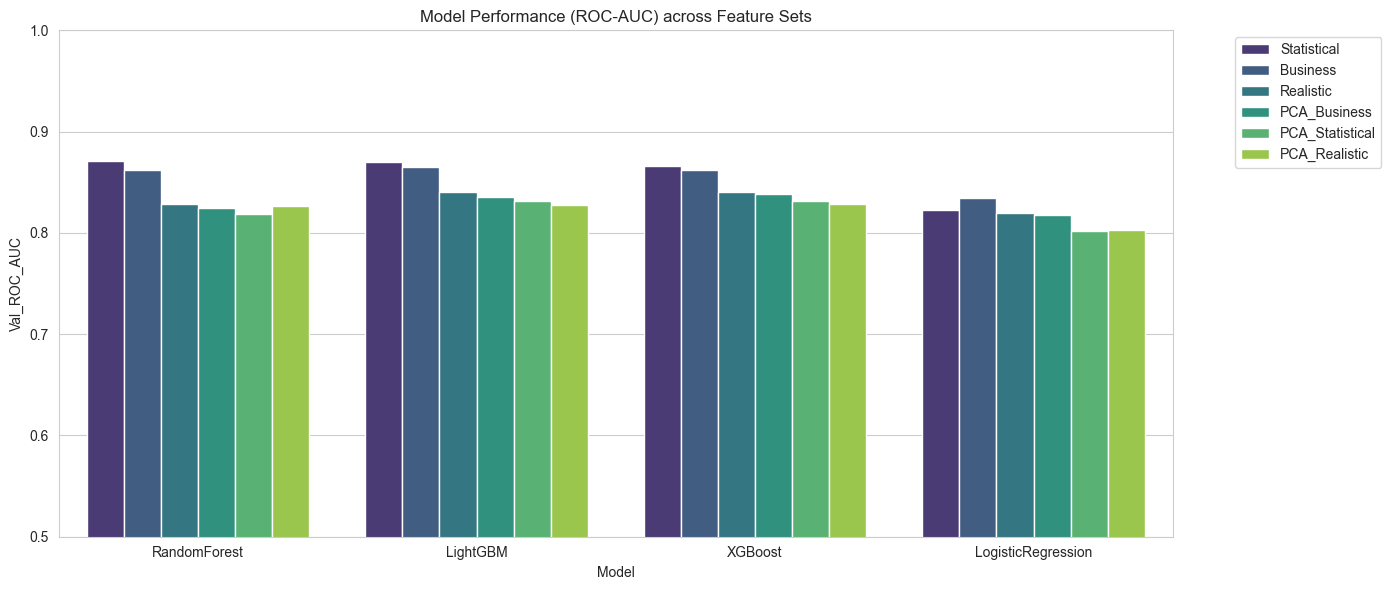

In [68]:
# Create Results DataFrame
results_df = pd.DataFrame(all_results)

if not results_df.empty:
    # Sort by ROC-AUC
    results_df = results_df.sort_values('Val_ROC_AUC', ascending=False)
    
    print("Top 10 Models by Validation ROC-AUC:")
    display(results_df[['Model', 'Dataset', 'Val_Accuracy', 'Val_ROC_AUC']].head(10))
    
    # Visualization
    plt.figure(figsize=(14, 6))
    sns.barplot(data=results_df, x='Model', y='Val_ROC_AUC', hue='Dataset', palette='viridis')
    plt.title('Model Performance (ROC-AUC) across Feature Sets')
    plt.ylim(0.5, 1.0)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("No results to display.")

## 4. Evaluation
In this section, we analyze the performance of the 30 experimental combinations (5 Models $\times$ 6 Feature Sets). We start with a high-level overview to identify patterns, select the best performing model, and then perform a detailed evaluation on the held-out Test Set.

### 4.1 Performance Overview
We visualize the results to identify the top performers and understand how different feature sets impact model performance.

Top 5 Models by Validation ROC-AUC:


,Model,Dataset,Best_Params,Val_Accuracy,Val_ROC_AUC,Training_Time,Model_Instance
6,RandomForest,Statistical,"{'max_depth': None, 'min_samples_split': 5, 'n...",0.894138,0.871396,39.137406,"(DecisionTreeClassifier(max_features='sqrt', m..."
18,LightGBM,Statistical,"{'device': 'gpu', 'learning_rate': 0.1, 'n_est...",0.892114,0.869731,32.854630,"LGBMClassifier(device='gpu', num_leaves=50, ra..."
12,XGBoost,Statistical,"{'device': 'cuda', 'eval_metric': 'logloss', '...",0.888904,0.866552,7.248765,"XGBClassifier(base_score=None, booster=None, c..."
20,LightGBM,Business,"{'device': 'gpu', 'learning_rate': 0.1, 'n_est...",0.887788,0.865183,28.698477,"LGBMClassifier(device='gpu', num_leaves=50, ra..."
14,XGBoost,Business,"{'device': 'cuda', 'eval_metric': 'logloss', '...",0.887718,0.862368,7.309035,"XGBClassifier(base_score=None, booster=None, c..."


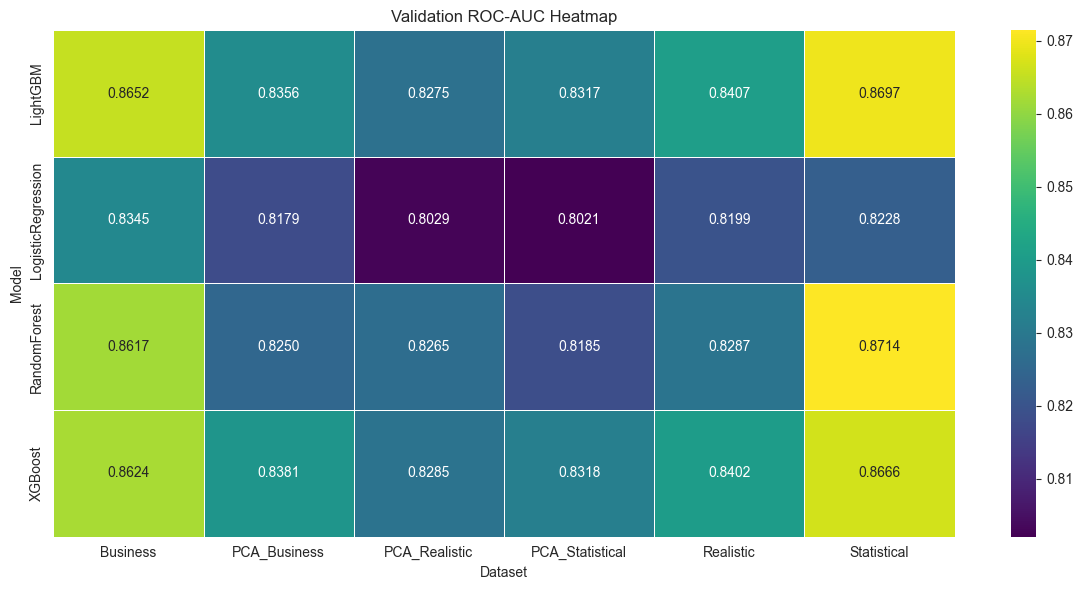

In [69]:
if not results_df.empty:
    print("Top 5 Models by Validation ROC-AUC:")
    display(results_df.sort_values('Val_ROC_AUC', ascending=False).head(5))

    # 2. Heatmap: Models vs Feature Sets
    pivot_table = results_df.pivot(index='Model', columns='Dataset', values='Val_ROC_AUC')
    
    plt.figure(figsize=(12, 6))
    sns.heatmap(pivot_table, annot=True, fmt=".4f", cmap='viridis', linewidths=.5)
    plt.title('Validation ROC-AUC Heatmap')
    plt.tight_layout()
    plt.show()

### 4.2 Feature Set & Model Analysis
We analyze the distribution of performance scores to determine which feature sets and algorithms are most robust.

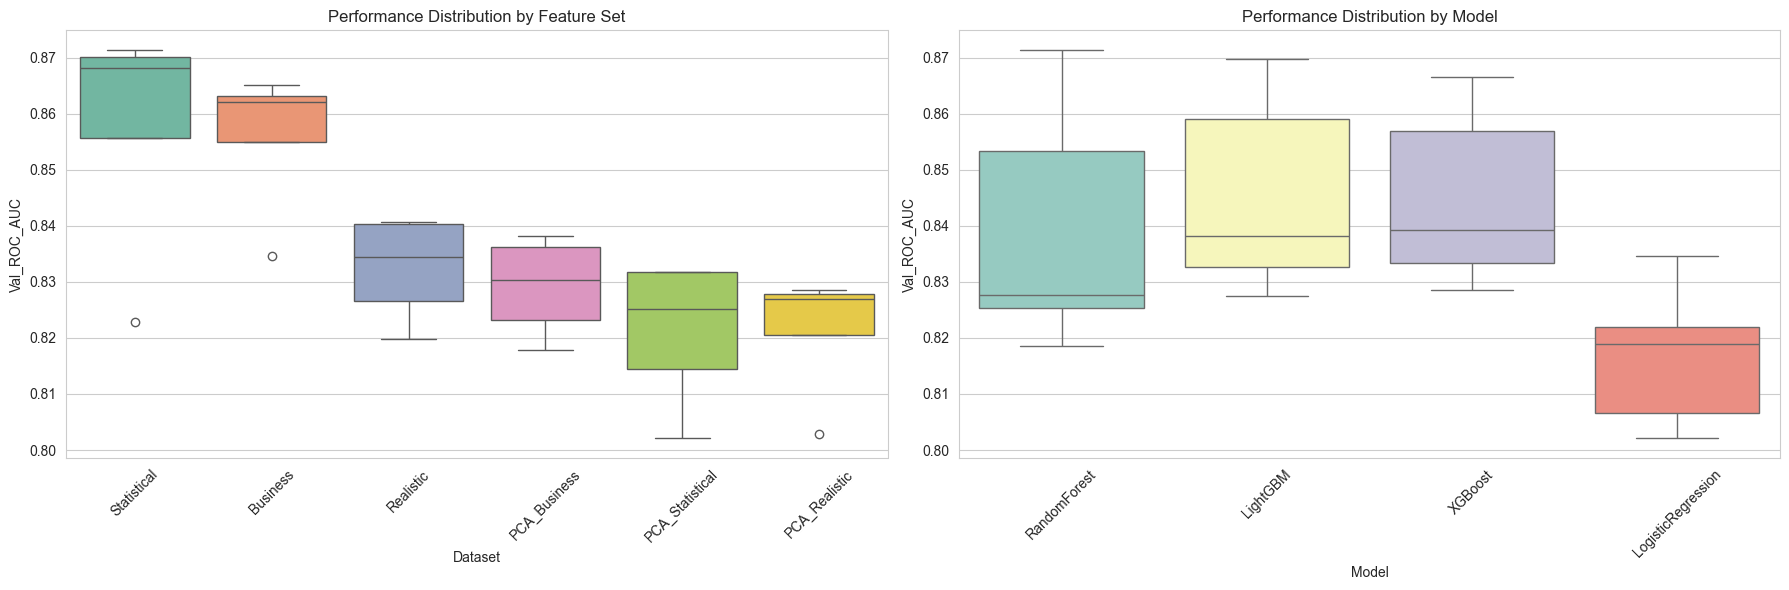

In [70]:
if not results_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Feature Set Comparison
    sns.boxplot(data=results_df, x='Dataset', y='Val_ROC_AUC', palette='Set2', ax=axes[0])
    axes[0].set_title('Performance Distribution by Feature Set')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Model Comparison
    sns.boxplot(data=results_df, x='Model', y='Val_ROC_AUC', palette='Set3', ax=axes[1])
    axes[1].set_title('Performance Distribution by Model')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

### 4.3 Best Model Evaluation on Test Set
We select the model with the highest Validation ROC-AUC and evaluate its performance on the held-out **Test Set** to confirm generalizability.

Best Model Selected: RandomForest on Statistical Set
Validation ROC-AUC: 0.8714

--- Test Set Performance ---
Accuracy: 0.9015
ROC-AUC : 0.8815

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95     12534
           1       0.76      0.31      0.44      1796

    accuracy                           0.90     14330
   macro avg       0.84      0.65      0.69     14330
weighted avg       0.89      0.90      0.88     14330



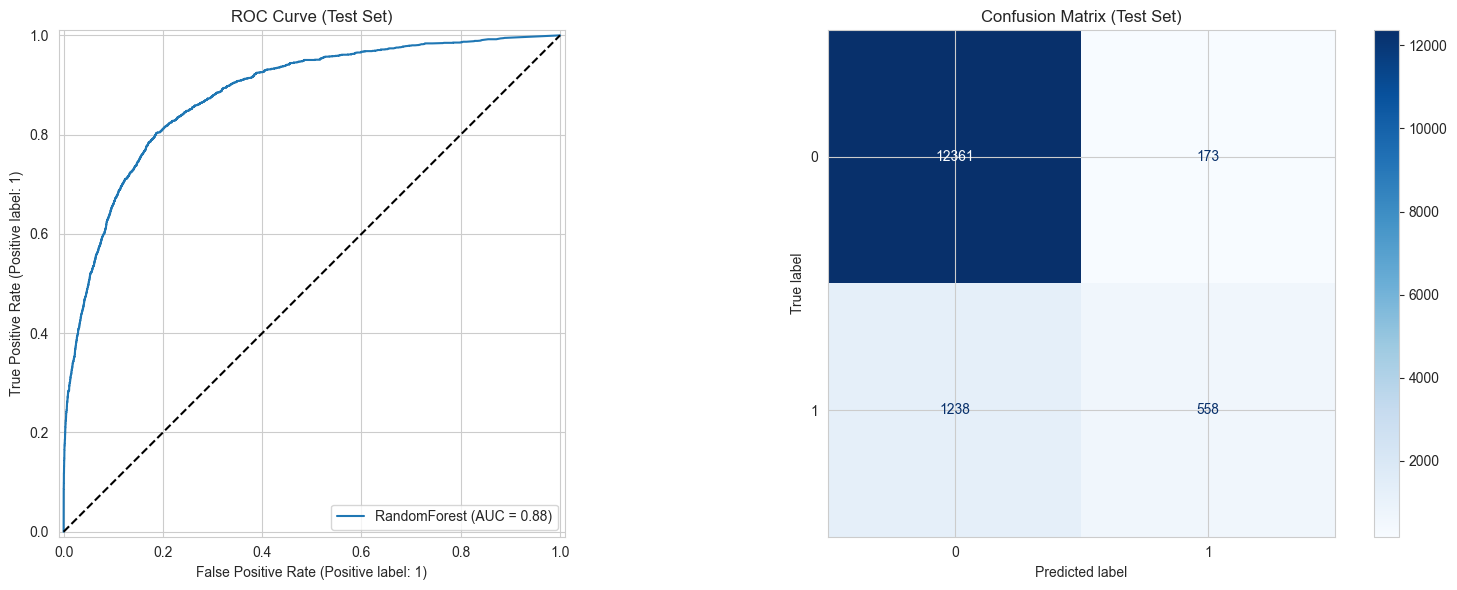

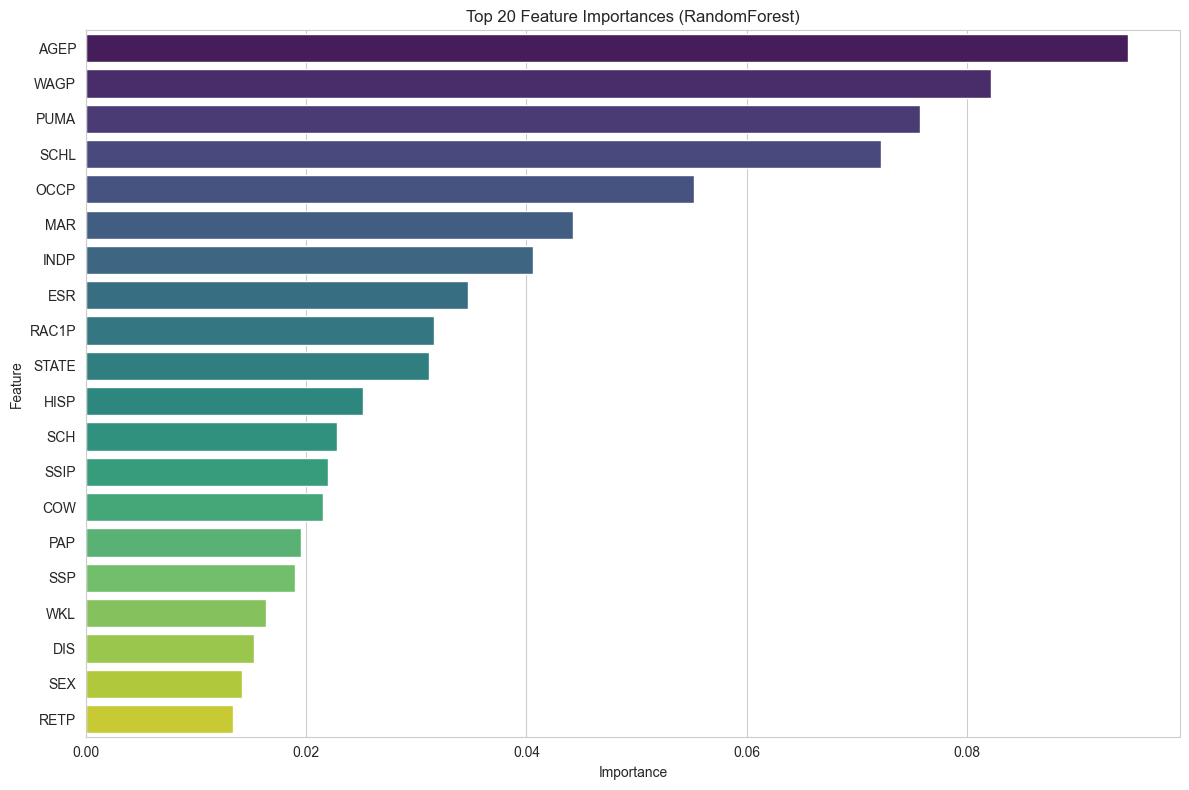

In [71]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

if not results_df.empty:
    # 1. Select Best Model
    best_row = results_df.sort_values('Val_ROC_AUC', ascending=False).iloc[0]
    best_model_name = best_row['Model']
    best_dataset_name = best_row['Dataset']
    best_model_instance = best_row['Model_Instance']
    
    print(f"Best Model Selected: {best_model_name} on {best_dataset_name} Set")
    print(f"Validation ROC-AUC: {best_row['Val_ROC_AUC']:.4f}")
    
    # 2. Retrieve Test Data
    if best_dataset_name in data_splits:
        X_test = data_splits[best_dataset_name]['X_test']
        y_test = data_splits[best_dataset_name]['y_test']
        
        # 3. Predict on Test Set
        y_pred_test = best_model_instance.predict(X_test)
        y_prob_test = best_model_instance.predict_proba(X_test)[:, 1] if hasattr(best_model_instance, "predict_proba") else y_pred_test
        
        # 4. Calculate Metrics
        test_acc = accuracy_score(y_test, y_pred_test)
        test_roc = roc_auc_score(y_test, y_prob_test)
        
        print(f"\n--- Test Set Performance ---")
        print(f"Accuracy: {test_acc:.4f}")
        print(f"ROC-AUC : {test_roc:.4f}")
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred_test))
        
        # 5. Visualizations
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # ROC Curve
        RocCurveDisplay.from_estimator(best_model_instance, X_test, y_test, ax=axes[0], name=f"{best_model_name}")
        axes[0].set_title("ROC Curve (Test Set)")
        axes[0].plot([0, 1], [0, 1], 'k--')
        
        # Confusion Matrix
        ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, cmap='Blues', ax=axes[1])
        axes[1].set_title("Confusion Matrix (Test Set)")
        
        plt.tight_layout()
        plt.show()
        
        # 6. Feature Importance (if applicable)
        if hasattr(best_model_instance, 'feature_importances_'):
            importances = best_model_instance.feature_importances_
            feature_names = X_test.columns
            
            # Create DataFrame
            fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
            fi_df = fi_df.sort_values('Importance', ascending=False).head(20)
            
            plt.figure(figsize=(12, 8))
            sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')
            plt.title(f'Top 20 Feature Importances ({best_model_name})')
            plt.tight_layout()
            plt.show()
            
    else:
        print(f"Error: Data split for {best_dataset_name} not found.")